### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 1: REPASAR ALGORITMOS SVM**
---
---

## REGRESIÓN LINEAL CON SVM Y UNA SOLA PREDICTORA

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

dataset = pd.read_csv('50_startups.csv')
X = dataset.iloc[:, 0].values.reshape(-1, 1)  # gasto en I+D
y = dataset.iloc[:, -1].values.reshape(-1, 1) # beneficios

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

# Escalador para X
escalador_X = StandardScaler()
X_train_escalado = escalador_X.fit_transform(X_train)
X_test_escalado = escalador_X.transform(X_test)

# Escalador para y
escalador_y = StandardScaler()
y_train_escalado = escalador_y.fit_transform(y_train)
y_test_escalado = escalador_y.transform(y_test)

# Resultados
media_X = escalador_X.mean_
desviacion_X = escalador_X.scale_
print(f"X_train y X_test escalados con media {media_X} y desviación {desviacion_X}")

media_y = escalador_y.mean_
desviacion_y = escalador_y.scale_
print(f"y_train e y_test escalados con media {media_y} y desviación {desviacion_y}")

X_train y X_test escalados con media [73794.29514286] y desviación [47471.20721458]
y_train e y_test escalados con media [111378.63228571] y desviación [41147.04958989]


In [25]:
from sklearn.svm import LinearSVR

svm = LinearSVR(epsilon=0.5, random_state=semilla)
svm.fit(X_train_escalado, y_train_escalado)

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearSVR(epsilon=0.5, random_state=546)

In [26]:
def calcula_vectores_soporte(svm, X, y):
    predicciones = svm.predict(X)
    fuera_del_margen = (np.abs(y - predicciones)) >= svm.epsilon
    return np.argwhere(fuera_del_margen)

svm.soporte_ = calcula_vectores_soporte(svm, X_train, y_train)


def plot_svm_regresion(svm, X, y, intervalo_ejes):
    x1s = np.linspace(intervalo_ejes[0], intervalo_ejes[1], 100).reshape(100, 1)
    y_pred = svm.predict(x1s)
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm.epsilon, "k--")
    plt.plot(x1s, y_pred - svm.epsilon, "k--")
    plt.scatter(X[svm.soporte_], y[svm.soporte_], s=180, facecolors="#FFAAAA")
    plt.plot(X, y, "bo")
    plt.xlabel(r"$x_1$", fontsize=16)
    plt.axis(intervalo_ejes)

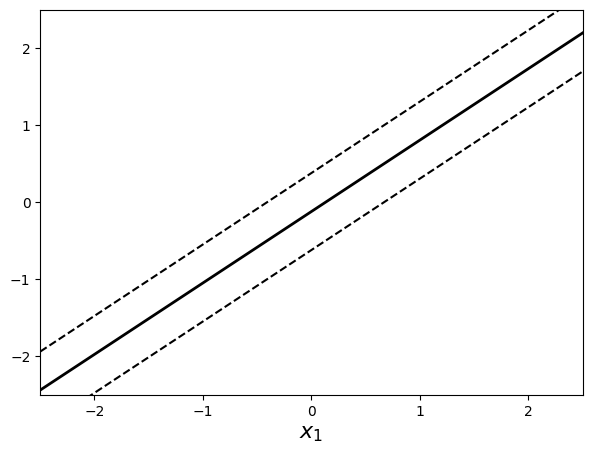

In [27]:
fig, ejes = plt.subplots(ncols=1, figsize=(7, 5), sharey=True)
plot_svm_regresion(svm=svm, X=X_train, y=y_train, intervalo_ejes=[-2.5, 2.5, -2.5, 2.5])

In [28]:
def plot_svm_regresion_completo(svm, X, y, intervalo_ejes, X_test=None, y_test=None, X_test_escalado=None):
    x1s = np.linspace(intervalo_ejes[0], intervalo_ejes[1], 100).reshape(100, 1)
    y_pred = svm.predict(x1s)
    
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm.epsilon, "k--")
    plt.plot(x1s, y_pred - svm.epsilon, "k--")
    
    plt.scatter(X[svm.soporte_], y[svm.soporte_], s=180, facecolors="#FFAAAA")
    plt.plot(X, y, "bo")
    
    if X_test is not None and y_test is not None:
        plt.scatter(X_test, y_test, c="green", label="test")
    
    if X_test_escalado is not None:
        y_pred_test = svm.predict(X_test_escalado)
        plt.scatter(X_test, y_pred_test, c="red", label="predicciones")
    
    plt.xlabel(r"$x_1$", fontsize=16)
    plt.axis(intervalo_ejes)
    plt.legend()

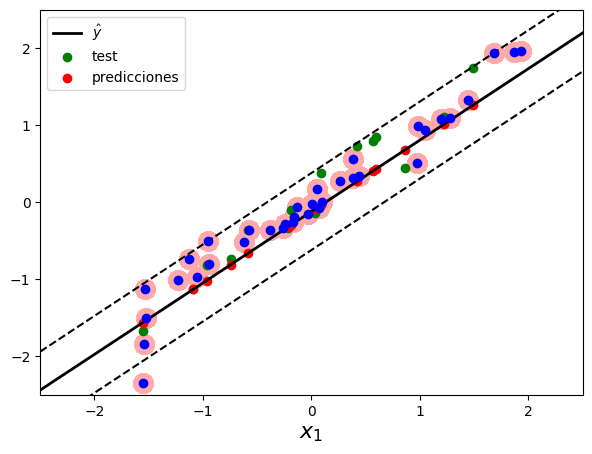

In [29]:
fig, ejes = plt.subplots(ncols=1, figsize=(7, 5), sharey=True)

plot_svm_regresion_completo(
    svm=svm,
    X=X_train_escalado,
    y=y_train_escalado,
    intervalo_ejes=[-2.5, 2.5, -2.5, 2.5],
    X_test=X_test_escalado,
    y_test=y_test_escalado,
    X_test_escalado=X_test_escalado,
)

In [30]:
from sklearn.metrics import r2_score

# Coeficientes y punto de corte
print("SVM Coeficientes:", svm.coef_)
print("SVM Corte:", svm.intercept_)

# Calcular R2 para entrenamiento y prueba
r2_train = r2_score(y_train_escalado, svm.predict(X_train_escalado))
r2_test = r2_score(y_test_escalado, svm.predict(X_test_escalado))

print("R2 train:", r2_train)
print("R2 test:", r2_test)

SVM Coeficientes: [0.92776621]
SVM Corte: [-0.12033758]
R2 train: 0.9311043909337999
R2 test: 0.9002195085269906


## ENTREGA 1: Muestra:
### a) Código y capturas de ejecución.
Se encuentra arriba.

### b) ¿Si SVR(kernel="linear") es equivalente a LinearSVR() qué diferencia hay entre ambos?
La diferencia es que SVR(kernel="linear") soporta kernels no lineales (como 'rbf' y 'poly') y te permite acceder a los vectores de soporte, mientras que LinearSVR() es más rápido con datasets grandes y te permite tener acceso directo a los coeficientes (mediante '.coef_' e '.intercept_')

### c) Puesto que es necesario escalar los datos para usar las máquinas de vector soporte, es más cómodo utilizar un pipeline que nos permita realizar las dos operaciones unificadas. Crea un pipeline con sklearn.pipeline.make_pipeline() que integre un objeto que normalice los datos y un LinearSVR() con epsilon 0.5 y tu semilla aleatoria, lo entrenas y vuelves a calcular el score sobre los datos de test ¿Coincide el score con el regresor anterior?

In [31]:
from sklearn.pipeline import make_pipeline

# Crear pipeline
svm_pipeline = make_pipeline(
    StandardScaler(),
    LinearSVR(epsilon=0.5, random_state=semilla)
)

svm_pipeline.fit(X_train, y_train)

# Predecir y calcular R2
y_pred_test = svm_pipeline.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)

print("R2 test:", r2_test)

R2 test: -9.511627375442902


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


El score no coincide con el regresor anterior, ya que el resultado de este en test ha sido de -9'511627375442902 y el resultado del anterior ha sido de 0'9002195085269906.

---
## CUANDO Y COMO USAR CADA POSIBLE REGRESOR SVM

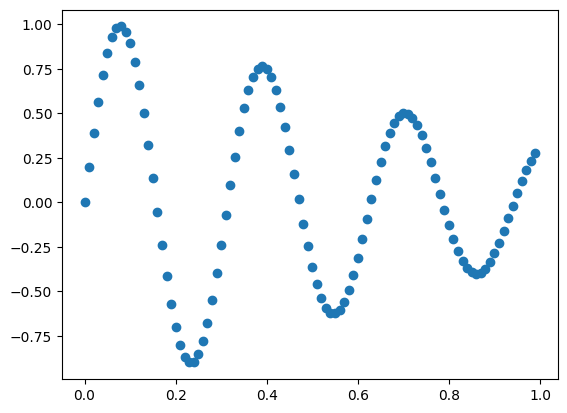

In [32]:
import numpy as np
import matplotlib.pyplot as plt

X = np.arange(0, 1, 0.01).reshape(-1, 1)
y = np.sin(20 * X) / (1 + 2 * X * X)
plt.scatter(X, y)

### SVR

C:\Users\davil\AppData\Local\Temp\ipykernel_14432\1894028542.py:10: RuntimeWarning: divide by zero encountered in divide
  error_percent1 = np.mean(np.abs((y - y_pred1) / y)) * 100
C:\Users\davil\AppData\Local\Temp\ipykernel_14432\1894028542.py:21: RuntimeWarning: divide by zero encountered in divide
  error_percent2 = np.mean(np.abs((y - y_pred2) / y)) * 100


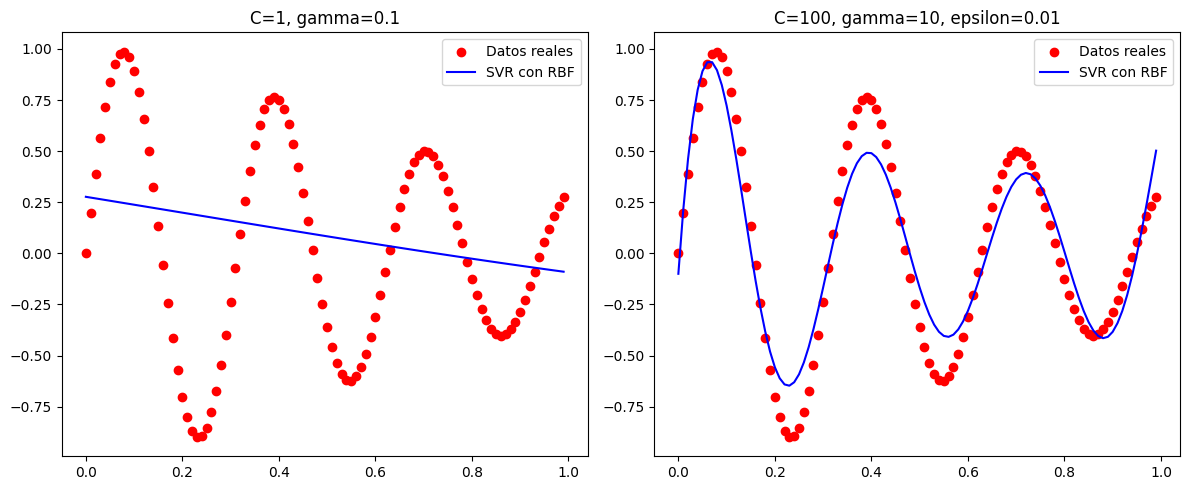

In [33]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Modelo SVR original
svr1 = SVR(kernel="rbf", C=1, gamma=0.1)
y_pred1 = svr1.fit(X, y.ravel()).predict(X)
mse1 = mean_squared_error(y, y_pred1)
error_percent1 = np.mean(np.abs((y - y_pred1) / y)) * 100

axs[0].scatter(X, y, color="red", label="Datos reales")
axs[0].plot(X, y_pred1, color="blue", label="SVR con RBF")
axs[0].set_title(f"C=1, gamma=0.1")
axs[0].legend()

# Modelo SVR ajustado
svr2 = SVR(kernel="rbf", C=100, gamma=10, epsilon=0.01)
y_pred2 = svr2.fit(X, y.ravel()).predict(X)
mse2 = mean_squared_error(y, y_pred2)
error_percent2 = np.mean(np.abs((y - y_pred2) / y)) * 100

axs[1].scatter(X, y, color="red", label="Datos reales")
axs[1].plot(X, y_pred2, color="blue", label="SVR con RBF")
axs[1].set_title(f"C=100, gamma=10, epsilon=0.01")
axs[1].legend()

plt.tight_layout()
plt.show()

In [34]:
print("Modelo inicial:")
print(f"MSE: {mse1:.6f} %Error: {error_percent1:.6f}%")

print("\nModelo mejorado:")
print(f"MSE: {mse2:.6f} %Error: {error_percent2:.6f}%")

Modelo inicial:
MSE: 0.240892 %Error: inf%

Modelo mejorado:
MSE: 0.021705 %Error: inf%


### NuSVR

C:\Users\davil\AppData\Local\Temp\ipykernel_14432\4117939146.py:9: RuntimeWarning: divide by zero encountered in divide
  error_percent1 = np.mean(np.abs((y - y_pred1) / y)) * 100
C:\Users\davil\AppData\Local\Temp\ipykernel_14432\4117939146.py:20: RuntimeWarning: divide by zero encountered in divide
  error_percent2 = np.mean(np.abs((y - y_pred2) / y)) * 100


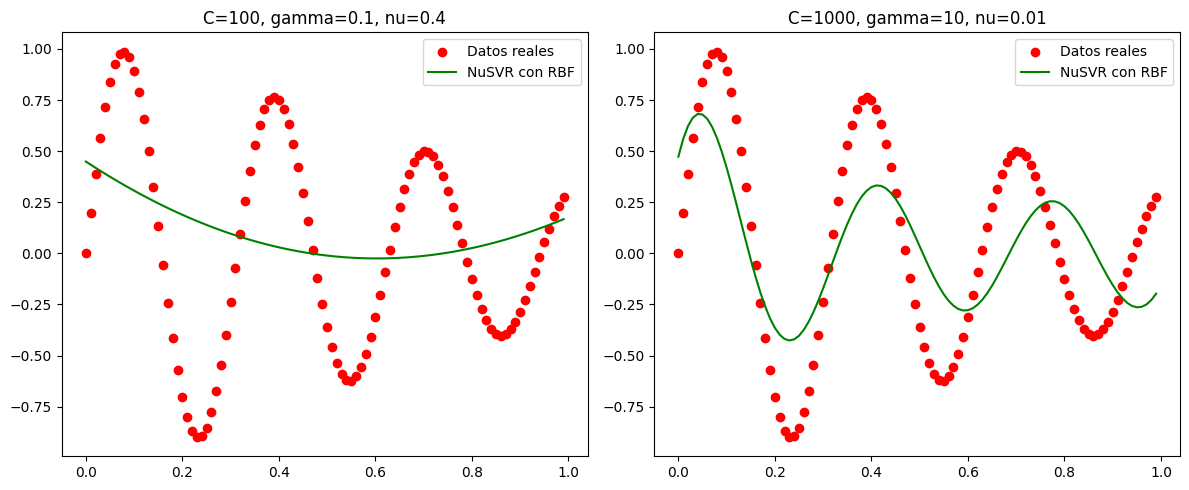

In [35]:
from sklearn.svm import NuSVR

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Modelo NuSVR original
nusvr1 = NuSVR(kernel="rbf", C=100, gamma=0.1, nu=0.4)
y_pred1 = nusvr1.fit(X, y.ravel()).predict(X)
mse1 = mean_squared_error(y, y_pred1)
error_percent1 = np.mean(np.abs((y - y_pred1) / y)) * 100

axs[0].scatter(X, y, color="red", label="Datos reales")
axs[0].plot(X, y_pred1, color="green", label="NuSVR con RBF")
axs[0].set_title(f"C=100, gamma=0.1, nu=0.4")
axs[0].legend()

# Modelo NuSVR ajustado
nusvr2 = NuSVR(kernel="rbf", C=1000, gamma=10, nu=0.01)
y_pred2 = nusvr2.fit(X, y.ravel()).predict(X)
mse2 = mean_squared_error(y, y_pred2)
error_percent2 = np.mean(np.abs((y - y_pred2) / y)) * 100

axs[1].scatter(X, y, color="red", label="Datos reales")
axs[1].plot(X, y_pred2, color="green", label="NuSVR con RBF")
axs[1].set_title(f"C=1000, gamma=10, nu=0.01")
axs[1].legend()

plt.tight_layout()
plt.show()

In [36]:
print("Modelo inicial:")
print(f"MSE: {mse1:.6f} %Error: {error_percent1:.6f}%")

print("\nModelo mejorado:")
print(f"MSE: {mse2:.6f} %Error: {error_percent2:.6f}%")

Modelo inicial:
MSE: 0.233818 %Error: inf%

Modelo mejorado:
MSE: 0.112173 %Error: inf%


### LinearSVR

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


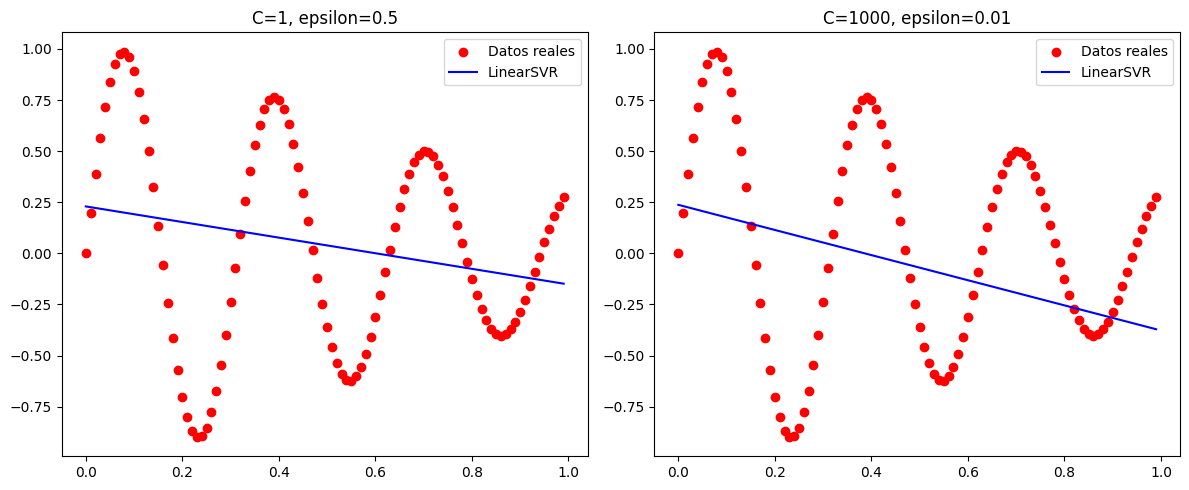

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Modelo LinearSVR original
linearsvr1 = LinearSVR(C=1.0, epsilon=0.5, max_iter=10000)
y_pred1 = linearsvr1.fit(X, y.ravel()).predict(X)
mse1 = mean_squared_error(y, y_pred1)
error_percent1 = np.mean(np.abs((y - y_pred1) / (np.abs(y) + 1e-8))) * 100

axs[0].scatter(X, y, color="red", label="Datos reales")
axs[0].plot(X, y_pred1, color="blue", label="LinearSVR")
axs[0].set_title(f"C=1, epsilon=0.5")
axs[0].legend()

# Modelo LinearSVR ajustado
linearsvr2 = LinearSVR(C=1000.0, epsilon=0.01, max_iter=10000)
y_pred2 = linearsvr2.fit(X, y.ravel()).predict(X)
mse2 = mean_squared_error(y, y_pred2)
error_percent2 = np.mean(np.abs((y - y_pred2) / (np.abs(y) + 1e-8))) * 100

axs[1].scatter(X, y, color="red", label="Datos reales")
axs[1].plot(X, y_pred2, color="blue", label="LinearSVR")
axs[1].set_title(f"C=1000, epsilon=0.01")
axs[1].legend()

plt.tight_layout()
plt.show()

In [38]:
print("Modelo inicial:")
print(f"MSE: {mse1:.6f} %Error: {error_percent1:.6f}%")

print("\nModelo mejorado:")
print(f"MSE: {mse2:.6f} %Error: {error_percent2:.6f}%")

Modelo inicial:
MSE: 0.239051 %Error: 9973722.310241%

Modelo mejorado:
MSE: 0.256615 %Error: 16098767.427403%


## ENTREGA 2: Muestra:
### a) Código y capturas de ejecución con gráficos previo y posterior y cálculos de MSE.
Se encuentra arriba.

---
## DETECCIÓN DE ANOMALÍAS CON REGRESORES

In [39]:
import numpy as np

# Generar datos de regresión con ruido
np.random.seed(semilla)  # cambia tu semilla!!
X = np.random.rand(100, 1) * 10  # Característica entre 0 y 10
y = 2 * X.flatten() + np.random.randn(100) * 2  # Línea distorsionada con ruido de amplitud 2

# Introducir outliers en los datos
outliers = np.random.randint(0, 100, 10)  # Seleccionamos 10 índices aleatorios
y[outliers] += np.random.randint(20, 50, size=10)  # Aumentamos el valor de esos puntos

Recta: 5.15 + 1.74*X
Recta con outliers= 5.147969931500009 + [1.737739859188424]X
Recta sin outliers= 5.069807594056169 + [1.6605011327773809]X


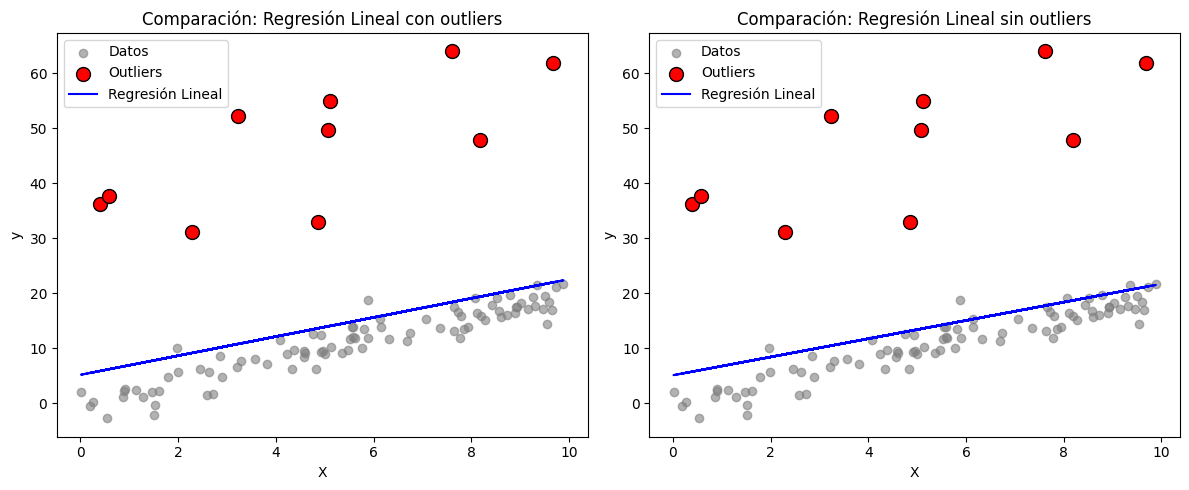

In [40]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Ajustar modelo de regresión lineal (con los outliers)
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)
print(f"Recta: {lr.intercept_:.2f} + {lr.coef_[0]:.2f}*X")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, y, color="gray", alpha=0.6, label="Datos")
plt.scatter(
    X[outliers], y[outliers], color="red", label="Outliers", edgecolor="black", s=100
)
plt.plot(X, y_pred_lr, color="blue", label="Regresión Lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Comparación: Regresión Lineal con outliers")

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_escalada = scaler.fit_transform(X)

# Entrenar OneClassSVM
oc_svm = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
oc_svm.fit(X_escalada)

# Máscara para los datos no outliers (1 = no outlier)
mascara = oc_svm.predict(X_escalada) == 1

# Filtrar datos sin outliers
X_sin_outliers = X[mascara]
y_sin_outliers = y[mascara]

# Ajustar modelo de regresión lineal sin outliers
lr_sin_outliers = LinearRegression()
lr_sin_outliers.fit(X_sin_outliers, y_sin_outliers)
y_pred_sin_outliers = lr_sin_outliers.predict(X)

# Resultados
print(f"Recta con outliers= {lr.intercept_} + [{lr.coef_[0]}]X")
print(
    f"Recta sin outliers= {lr_sin_outliers.intercept_} + [{lr_sin_outliers.coef_[0]}]X"
)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color="gray", alpha=0.6, label="Datos")
plt.scatter(
    X[outliers], y[outliers], color="red", label="Outliers", edgecolor="black", s=100
)
plt.plot(X, y_pred_sin_outliers, color="blue", label="Regresión Lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Comparación: Regresión Lineal sin outliers")
plt.tight_layout()
plt.show()

## ENTREGA 3: Muestra:
### a) Capturas de ejecución y el código donde aparezcan fórmulas del modelo y gráficos de predicciones del modelo de regresión lineal con outliers y una vez eliminados tras detectarlos con OneClassSVM.
Se encuentra arriba.

### b) Capturas de ejecución y el código donde aparezcan fórmulas del modelo y gráficos de predicciones del modelo de regresión lineal con outliers y una vez eliminados tras detectarlos con RANSAC.
Se encuentra abajo.

Recta con outliers= 5.147969931500009 + [1.737739859188424]X
Recta sin outliers (RANSAC)= -0.06568965447260666 + [2.0051447320335742]X


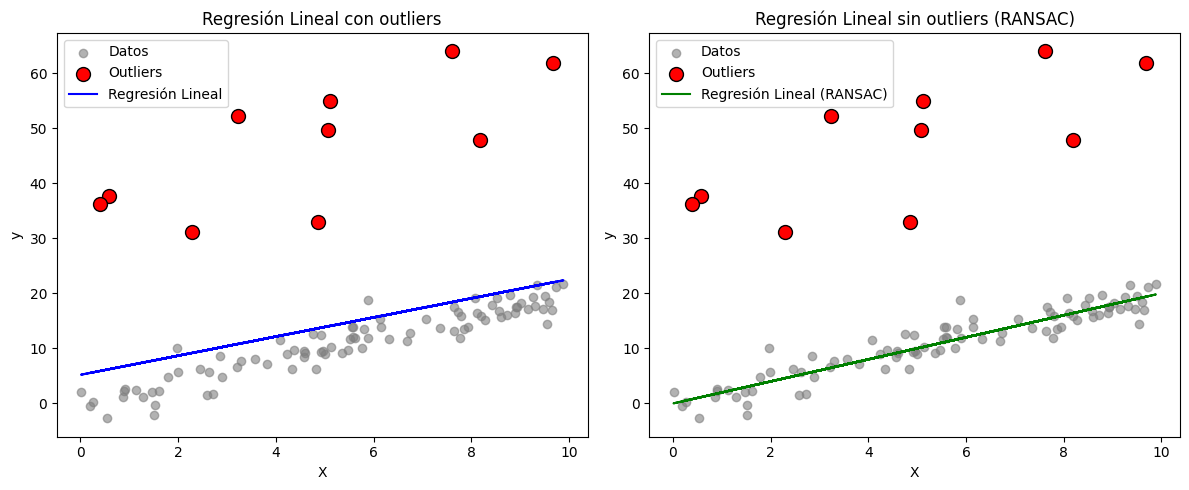

In [41]:
from sklearn.linear_model import RANSACRegressor

# Modelo
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    max_trials=100,
    residual_threshold=10,
    random_state=semilla,
)

# Entrenar y predecir con RANSAC
ransac.fit(X, y)
y_pred_ransac = ransac.predict(X)

# Máscara
mascara_ransac = ransac.inlier_mask_
X_ransac = X[mascara_ransac]
y_ransac = y[mascara_ransac]

# Reentrenar modelo lineal con datos filtrados
lr_ransac = LinearRegression()
lr_ransac.fit(X_ransac, y_ransac)

# Resultados
print(f"Recta con outliers= {lr.intercept_} + [{lr.coef_[0]}]X")
print(f"Recta sin outliers (RANSAC)= {lr_ransac.intercept_} + [{lr_ransac.coef_[0]}]X")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, y, color="gray", alpha=0.6, label="Datos")
plt.scatter(
    X[~mascara_ransac],
    y[~mascara_ransac],
    color="red",
    label="Outliers",
    edgecolor="black",
    s=100,
)
plt.plot(X, y_pred_lr, color="blue", label="Regresión Lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Lineal con outliers")

plt.subplot(1, 2, 2)
plt.scatter(X, y, color="gray", alpha=0.6, label="Datos")
plt.scatter(
    X[~mascara_ransac],
    y[~mascara_ransac],
    color="red",
    label="Outliers",
    edgecolor="black",
    s=100,
)
plt.plot(X, y_pred_ransac, color="green", label="Regresión Lineal (RANSAC)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Lineal sin outliers (RANSAC)")
plt.tight_layout()
plt.show()

---
## UTILIZACIÓN DE KERNELS

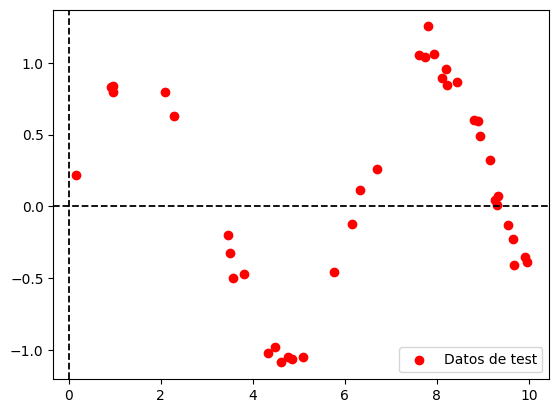

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generar datos artificiales (con ruido)
np.random.seed(semilla)  # Semilla 449 porque Jose = 4 Rosa=4 Rodriguez=9
X = np.sort(10 * np.random.rand(200, 1), axis=0)  # Entrada (200 ejemplos)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # Salida con ruido

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

# Calcular rango de los datos para calcular la magnitud porcentual del error
rango = y.max() - y.min()

# Graficar resultados
plt.scatter(X_test, y_test, color="red", label="Datos de test")
plt.legend()
plt.axhline(0, color='black', linewidth=1.3, linestyle='--')  # Eje horizontal (y=0)
plt.axvline(0, color='black', linewidth=1.3, linestyle='--')  # Eje vertical
plt.show()

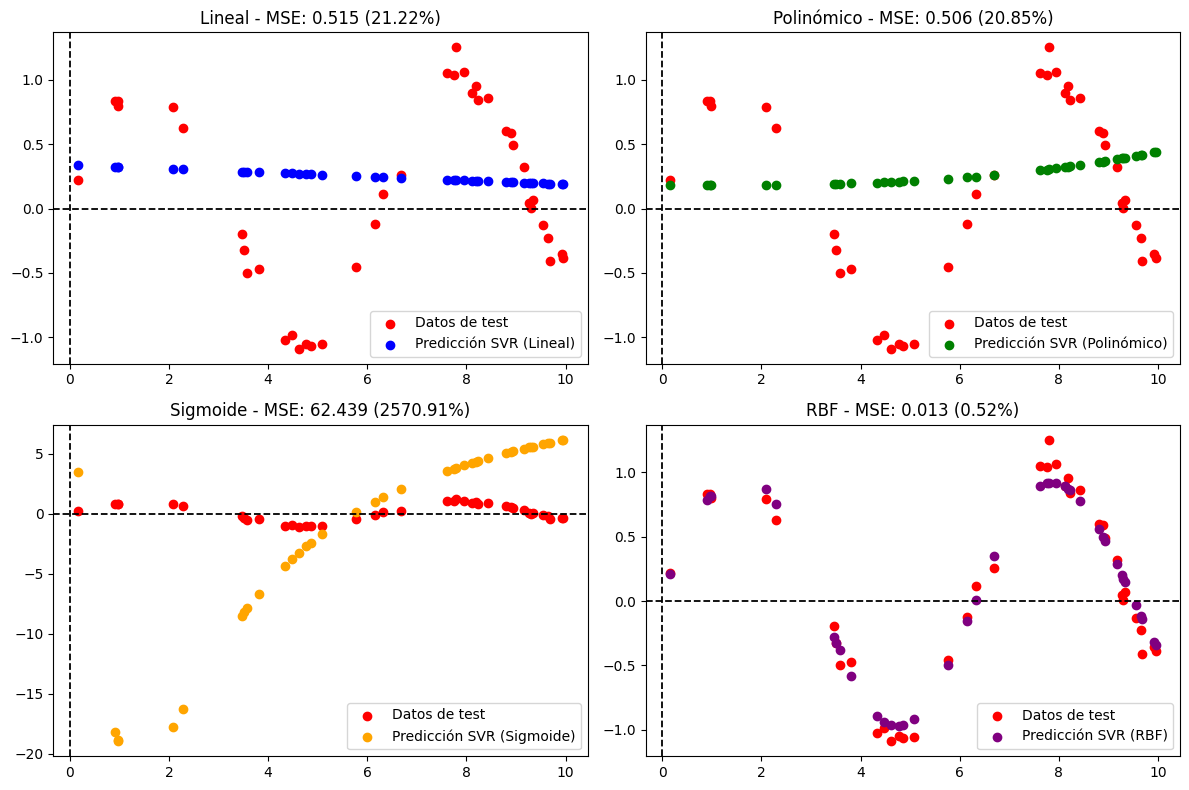

In [43]:
# Parámetros
C = 1
epsilon = 0.1
kernels = ['linear', 'poly', 'sigmoid', 'rbf']
colores = ['blue', 'green', 'orange', 'purple']
titulos = ['Lineal', 'Polinómico', 'Sigmoide', 'RBF']

# Figura
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for i, kernel in enumerate(kernels):
    # Entrenar SVR
    svr = SVR(kernel=kernel, C=C, epsilon=epsilon)
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)

    # Calcular errores
    mse = mean_squared_error(y_test, y_pred)
    error_porcentual = (mse / rango) * 100

    # Visualizar
    axs[i].scatter(X_test, y_test, color='red', label='Datos de test')
    axs[i].scatter(X_test, y_pred, color=colores[i], label=f'Predicción SVR ({titulos[i]})')
    axs[i].axhline(0, color='black', linewidth=1.3, linestyle='--')
    axs[i].axvline(0, color='black', linewidth=1.3, linestyle='--')
    axs[i].legend()
    axs[i].set_title(f"{titulos[i]} - MSE: {mse:.3f} ({error_porcentual:.2f}%)")

plt.tight_layout()
plt.show()
